<a href="https://colab.research.google.com/github/aleksandrabegovic/apple_sentiment_analiza/blob/main/SentimentGoogle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip -q install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
#Potrebne biblioteke za dalje analize.

In [3]:
from google.colab import files
uploaded = files.upload()
#Podaci su učitani u okruženje, nakon čega su dalje obrađeni.

Saving apple_news_data.csv to apple_news_data.csv


In [4]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.shape, df.columns
#Prikaz osnovnih informacija o datasetu, broj redova, broj kolona, kao i informacija o tome koje sve kolone postoje.

((29752, 10),
 Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
        'sentiment_polarity', 'sentiment_neg', 'sentiment_neu',
        'sentiment_pos'],
       dtype='object'))

In [5]:
df.head(5)
#Prikaz prvih 5 redova, kako bismo videli sa kojim podacima radimo.

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [6]:
df["date"] = pd.to_datetime(df["date"])
df[["date"]].head()
# Konverzija kolone 'date' u datetime format radi vremenskog
# usklađivanja finansijskih vesti sa podacima o cenama akcija.

,date
0,2024-11-27 16:39:00+00:00
1,2024-11-26 00:00:00+00:00
2,2024-11-26 00:00:00+00:00
3,2024-11-26 00:00:00+00:00
4,2024-11-26 00:00:00+00:00


In [7]:
googl_df = df[df["symbols"].str.contains("GOOGL.US", na=False)].copy()

print("Broj GOOGL.US vesti:", len(googl_df))

Broj GOOGL.US vesti: 3662


In [8]:
googl_df['date'] = pd.to_datetime(googl_df['date'])
googl_df['year'] = googl_df['date'].dt.year

print(googl_df['year'].value_counts().sort_index())

year
2020      53
2021    1584
2022     887
2023     873
2024     265
Name: count, dtype: int64


In [9]:
random_news = googl_df.sample(1)

print("DATUM:", random_news["date"].values[0])
print("NASLOV:", random_news["title"].values[0])
print("TEKST:", random_news["content"].values[0])

DATUM: 2021-02-12T21:34:48.000000000
NASLOV: Google, Microsoft, Qualcomm Protest Nvidia’s Acquisition of Arm Ltd.
TEKST: (Bloomberg) -- Some of the world’s largest technology companies are complaining to U.S. antitrust regulators about Nvidia Corp.’s acquisition of Arm Ltd. because the deal will harm competition in an area of the industry that is vital to their businesses.

Alphabet Inc.’s Google, Microsoft Corp. and Qualcomm Inc. are among companies worried about the $40 billion deal and are urging antitrust officials to intervene, said people familiar with the process who asked not to be identified because they weren’t authorized to speak publicly. At least one of the companies wants the deal killed. Nvidia shares fell as much as 3.1% in New York trading on Friday.

The acquisition would give Nvidia control over a critical supplier that licenses essential chip technology to the likes of Apple Inc., Intel Corp., Samsung Electronics Co., Amazon.com Inc. and China’s Huawei Technologies 

In [10]:
!pip install yfinance

In [11]:
import yfinance as yf
import pandas as pd

In [12]:
google_prices = yf.download("GOOGL", start="2020-01-01", end="2024-12-31")

google_prices = google_prices.reset_index()

google_prices = google_prices.rename(columns={
    "Date": "date",
    "Close": "close"
})

/tmp/ipykernel_18321/1179417932.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google_prices = yf.download("GOOGL", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [13]:
googl_df["date"] = pd.to_datetime(googl_df["date"]).dt.date
google_prices["date"] = pd.to_datetime(google_prices["date"]).dt.date


googl_df["date"] = pd.to_datetime(googl_df["date"])
google_prices["date"] = pd.to_datetime(google_prices["date"])


googl_df = googl_df.sort_values("date")
google_prices = google_prices.sort_values("date")


google_prices.columns = google_prices.columns.droplevel(1)
google_prices = google_prices.rename(columns={"Close": "close"})

In [14]:
import pandas as pd

# 1) priprema price tabele
google_prices = google_prices.sort_values("date").copy()

google_prices["close_t"] = google_prices["close"]
google_prices["close_t1"] = google_prices["close"].shift(-1)
google_prices["close_t2"] = google_prices["close"].shift(-2)
google_prices["close_t3"] = google_prices["close"].shift(-3)
google_prices["close_t5"] = google_prices["close"].shift(-5)
google_prices["close_t7"] = google_prices["close"].shift(-7)

google_prices["open_t1"] = google_prices["Open"].shift(-1)
google_prices["open_t2"] = google_prices["Open"].shift(-2)

google_prices["high_t1"] = google_prices["High"].shift(-1)
google_prices["high_t2"] = google_prices["High"].shift(-2)
google_prices["high_t3"] = google_prices["High"].shift(-3)

google_prices["low_t1"] = google_prices["Low"].shift(-1)
google_prices["low_t2"] = google_prices["Low"].shift(-2)
google_prices["low_t3"] = google_prices["Low"].shift(-3)

google_prices["avg_t"] = (
    google_prices["Open"] +
    google_prices["High"] +
    google_prices["Low"] +
    google_prices["close"]
) / 4

google_prices["avg_t1"] = google_prices["avg_t"].shift(-1)

# 2) merge vesti, sledeći trading dan
googl_merged = pd.merge_asof(
    googl_df.sort_values("date"),
    google_prices[[
        "date",
        "close_t", "close_t1", "close_t2", "close_t3",
        "close_t5", "close_t7",
        "open_t1", "open_t2",
        "high_t1", "high_t2", "high_t3",
        "low_t1", "low_t2", "low_t3",
        "avg_t", "avg_t1"
    ]],
    on="date",
    direction="forward"
)

# 3) osnovni prinosi
googl_merged["return_close_close"] = (
    googl_merged["close_t1"] - googl_merged["close_t"]
) / googl_merged["close_t"]

googl_merged["return_open_close"] = (
    googl_merged["close_t1"] - googl_merged["open_t1"]
) / googl_merged["open_t1"]

googl_merged["return_open_open"] = (
    googl_merged["open_t2"] - googl_merged["open_t1"]
) / googl_merged["open_t1"]

googl_merged["return_avg_avg"] = (
    googl_merged["avg_t1"] - googl_merged["avg_t"]
) / googl_merged["avg_t"]

# 4) dodatni prinosi za 2, 3, 5 i 7 dana
googl_merged["return_2d"] = (
    googl_merged["close_t2"] - googl_merged["close_t"]
) / googl_merged["close_t"]

googl_merged["return_3d"] = (
    googl_merged["close_t3"] - googl_merged["close_t"]
) / googl_merged["close_t"]

googl_merged["return_5d"] = (
    googl_merged["close_t5"] - googl_merged["close_t"]
) / googl_merged["close_t"]

googl_merged["return_7d"] = (
    googl_merged["close_t7"] - googl_merged["close_t"]
) / googl_merged["close_t"]

# 5) targeti za neuronsku mrežu
googl_merged["y_1d"] = (googl_merged["return_close_close"] > 0).astype(int)
googl_merged["y_2d"] = (googl_merged["return_2d"] > 0).astype(int)
googl_merged["y_3d"] = (googl_merged["return_3d"] > 0).astype(int)
googl_merged["y_5d"] = (googl_merged["return_5d"] > 0).astype(int)
googl_merged["y_7d"] = (googl_merged["return_7d"] > 0).astype(int)

# 6) profesorov target
googl_merged["max_high_3d"] = googl_merged[["high_t1", "high_t2", "high_t3"]].max(axis=1)
googl_merged["min_low_3d"] = googl_merged[["low_t1", "low_t2", "low_t3"]].min(axis=1)

googl_merged["up_move_3d"] = googl_merged["max_high_3d"] - googl_merged["close_t"]
googl_merged["down_move_3d"] = googl_merged["min_low_3d"] - googl_merged["close_t"]

googl_merged["y_prof_3d"] = (
    abs(googl_merged["up_move_3d"]) > abs(googl_merged["down_move_3d"])
).astype(int)

# 7) kompanija
googl_merged["company"] = "GOOGL"

# 8) čišćenje
googl_merged = googl_merged.dropna(subset=[
    "return_close_close",
    "return_2d",
    "return_3d",
    "return_5d",
    "return_7d",
    "max_high_3d",
    "min_low_3d"
])

print(googl_merged.shape)
googl_merged.head()

(3662, 46)


,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos,...,y_2d,y_3d,y_5d,y_7d,max_high_3d,min_low_3d,up_move_3d,down_move_3d,y_prof_3d,company
0,2020-03-30,Buying What the Fed Buys,"On Monday, March 23, the Federal Reserve annou...",https://finance.yahoo.com/news/buying-fed-buys...,"AAPL.US, AMZN.US, FB.US, GOOGL.US, IGSB.US, JP...","BOND ETF, CORPORATE BOND ETF, CORPORATE BONDS,...",0.992,0.057,0.846,0.098,...,0,0,1,1,58.154331,54.176111,1.342598,-2.635623,0,GOOGL
1,2020-05-12,Not Just Fun And Games: How Esports Could Offe...,Like to play Fortnite or League of Legends? Yo...,https://finance.yahoo.com/news/not-just-fun-ga...,"AAPL.US, AMZN.US, DATA.LSE, GOOG.US, GOOGL.US,...","GLOBALDATA, GOOGL, LEAGUE OF LEGENDS, NASDAQ",0.997,0.015,0.888,0.097,...,0,0,0,1,68.657705,65.583459,0.503042,-2.571204,0,GOOGL
2,2020-05-13,Keep Your Virus News Away From My Ad: Brands B...,(Bloomberg) -- Readers are flocking to news si...,https://finance.yahoo.com/news/blizzard-corona...,"AAPL.US, FB.US, GOOG.US, GOOGL.US, IBM.US, MRR...","BLOOMBERG, BRITISH NEWS INDUSTRY, CORONAVIRUS,...",-0.950,0.088,0.841,0.071,...,1,1,1,1,69.025935,65.583459,2.201976,-1.240501,1,GOOGL
3,2020-05-14,Sony Says It Created World’s First Image Senso...,(Bloomberg) -- Sony Corp. touted on Thursday t...,https://finance.yahoo.com/news/sony-says-creat...,"AAPL.US, GOOG.US, GOOGL.US, NINOF.US, NINOY.US...","ARTIFICIAL INTELLIGENCE, BLOOMBERG, IMAGE RECO...",0.994,0.003,0.869,0.128,...,1,1,1,1,69.025935,66.361541,1.779224,-0.885170,1,GOOGL
4,2020-05-19,"Sony, Microsoft Strike Deal on Tiny AI Chip Wi...",(Bloomberg) -- Sony Corp. and Microsoft Corp. ...,https://finance.yahoo.com/news/sony-microsoft-...,"AAPL.US, GOOG.US, GOOGL.US, MSFT.US, NINOF.US,...","APPLE INC, BLOOMBERG, COMMERCIAL CUSTOMERS, ED...",0.998,0.015,0.851,0.134,...,1,1,1,1,70.227275,68.761271,2.111278,0.645273,1,GOOGL


In [15]:
googl_merged[["date", "title", "close_t", "close_t1", "return_close_close","return_open_open","return_open_close","return_avg_avg"]].head()

,date,title,close_t,close_t1,return_close_close,return_open_open,return_open_close,return_avg_avg
0,2020-03-30,Buying What the Fed Buys,56.811733,57.586864,0.013644,-0.021528,0.011508,0.020396
1,2020-05-12,Not Just Fun And Games: How Esports Could Offe...,68.154663,66.823959,-0.019525,-0.030985,-0.020223,-0.024121
2,2020-05-13,Keep Your Virus News Away From My Ad: Brands B...,66.823959,67.246712,0.006326,0.011053,0.017503,-0.012281
3,2020-05-14,Sony Says It Created World’s First Image Senso...,67.246712,68.049576,0.011939,0.009880,0.018394,0.011888
4,2020-05-19,"Sony, Microsoft Strike Deal on Tiny AI Chip Wi...",68.115997,69.838715,0.025291,0.015715,0.014397,0.012964


In [16]:
d = pd.to_datetime("2021-07-28")

googl_merged[googl_merged["date"].dt.date == d.date()][["close_t","close_t1"]].drop_duplicates()

,close_t,close_t1
1035,134.897827,134.584106


In [17]:
googl_merged["direction_close_close"] = googl_merged["return_close_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

googl_merged["direction_open_open"] = googl_merged["return_open_open"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

googl_merged["direction_open_close"] = googl_merged["return_open_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

googl_merged["direction_avg_avg"] = googl_merged["return_avg_avg"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

In [ ]:
googl_merged["direction_close_close"].value_counts()

,count
direction_close_close,
UP,1965
DOWN,1697


In [ ]:
googl_merged["direction_open_open"].value_counts()

,count
direction_open_open,
UP,1939
DOWN,1723


In [ ]:
googl_merged["direction_open_close"].value_counts()

,count
direction_open_close,
UP,1915
DOWN,1747


In [ ]:
googl_merged["direction_avg_avg"].value_counts()

,count
direction_avg_avg,
UP,1944
DOWN,1718


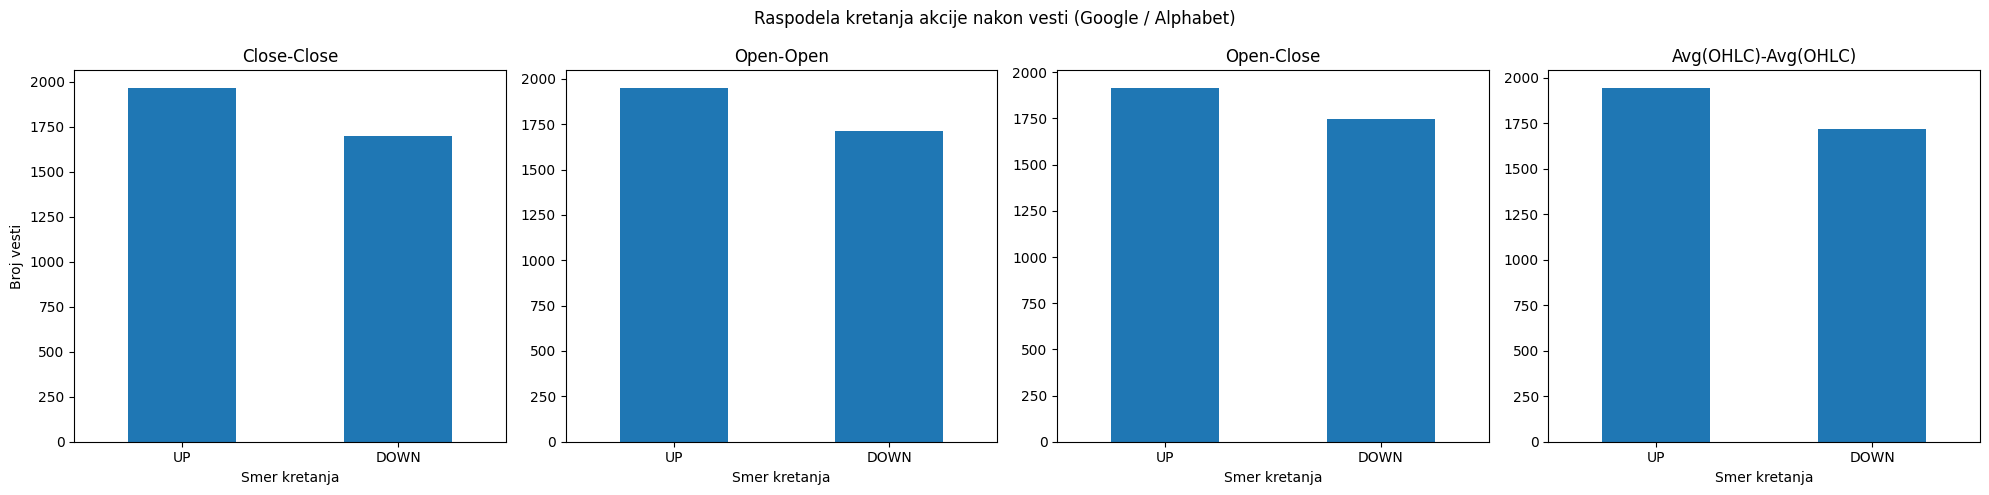

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# close-close
googl_merged["direction_close_close"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Close-Close")
axes[0].set_xlabel("Smer kretanja")
axes[0].set_ylabel("Broj vesti")
axes[0].tick_params(axis='x', rotation=0)

# open-open
googl_merged["direction_open_open"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Open-Open")
axes[1].set_xlabel("Smer kretanja")
axes[1].tick_params(axis='x', rotation=0)

# open-close
googl_merged["direction_open_close"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Open-Close")
axes[2].set_xlabel("Smer kretanja")
axes[2].tick_params(axis='x', rotation=0)

# avg-avg
googl_merged["direction_avg_avg"].value_counts().plot(
    kind="bar", ax=axes[3]
)
axes[3].set_title("Avg(OHLC)-Avg(OHLC)")
axes[3].set_xlabel("Smer kretanja")
axes[3].tick_params(axis='x', rotation=0)

plt.suptitle("Raspodela kretanja akcije nakon vesti (Google / Alphabet)")

plt.tight_layout()
plt.show()

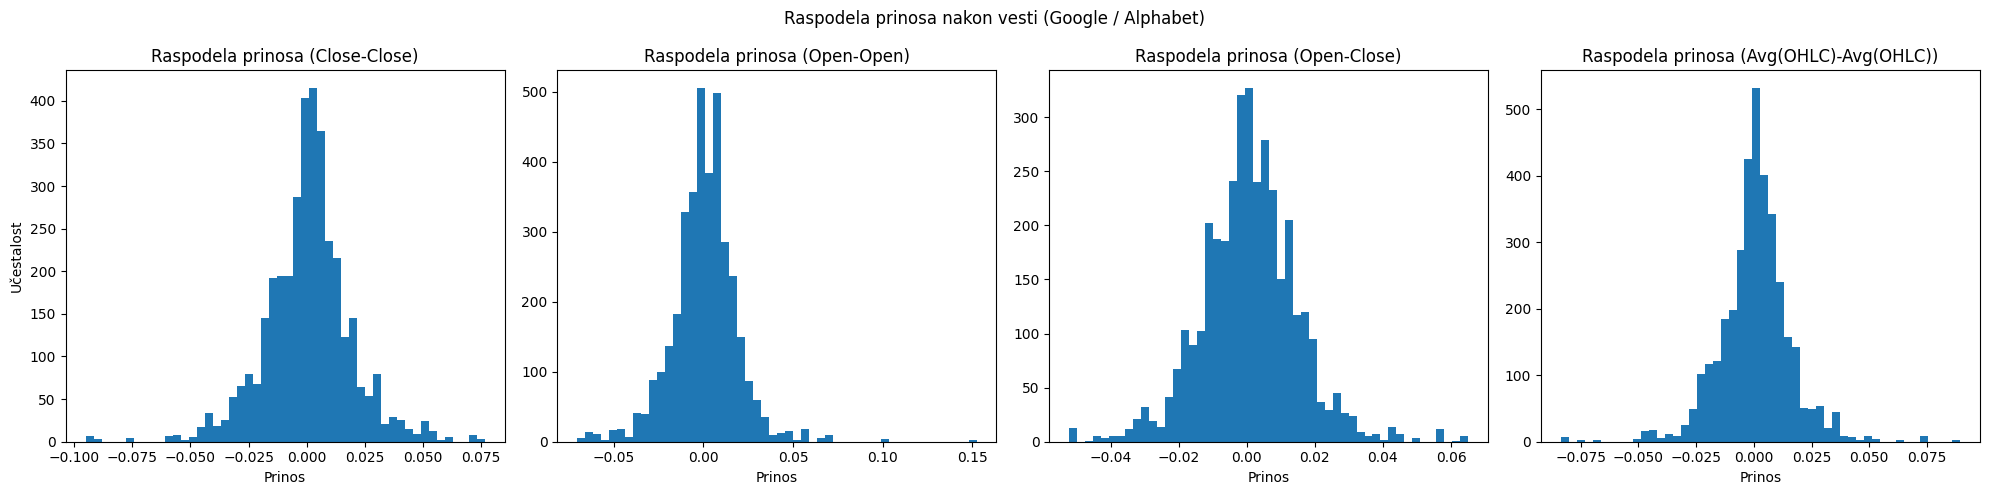

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# Close-Close
axes[0].hist(googl_merged["return_close_close"].dropna(), bins=50)
axes[0].set_title("Raspodela prinosa (Close-Close)")
axes[0].set_xlabel("Prinos")
axes[0].set_ylabel("Učestalost")

# Open-Open
axes[1].hist(googl_merged["return_open_open"].dropna(), bins=50)
axes[1].set_title("Raspodela prinosa (Open-Open)")
axes[1].set_xlabel("Prinos")

# Open-Close
axes[2].hist(googl_merged["return_open_close"].dropna(), bins=50)
axes[2].set_title("Raspodela prinosa (Open-Close)")
axes[2].set_xlabel("Prinos")

# Avg-Avg
axes[3].hist(googl_merged["return_avg_avg"].dropna(), bins=50)
axes[3].set_title("Raspodela prinosa (Avg(OHLC)-Avg(OHLC))")
axes[3].set_xlabel("Prinos")

plt.suptitle("Raspodela prinosa nakon vesti (Google / Alphabet)")

plt.tight_layout()
plt.show()

In [ ]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [ ]:
from typing import Optional
from enum import Enum
from pydantic import BaseModel, Field


class Sentiment(str, Enum):
    NEGATIVE = "negative"
    NEUTRAL = "neutral"
    POSITIVE = "positive"


class Topic(str, Enum):
    SEARCH = "search_engine"
    ADVERTISING = "digital_advertising"
    YOUTUBE = "youtube_platform"
    AI = "ai_ml"
    CLOUD = "google_cloud"
    ANDROID = "android_ecosystem"
    REGULATION = "regulation_antitrust"
    LEGAL = "legal_lawsuit"
    PRIVACY = "data_privacy_security"
    MACRO = "macro_economy_rates_inflation"
    MERGERS = "mna_partnerships"
    OTHER = "other"


class NewsAnnotation(BaseModel):
    """Structured annotation for Google (Alphabet)-related financial news."""

    sentiment: Optional[Sentiment] = Field(
        default=None,
        description="Overall sentiment expressed toward Google (Alphabet) in the news.",
        examples=[Sentiment.NEGATIVE]
    )

    sentiment_score: Optional[float] = Field(
        default=None,
        description="Sentiment score between -1 and 1 where -1 is very negative, 0 neutral, and 1 very positive.",
        examples=[-0.8, 0.0, 0.7]
    )

    topic: Optional[Topic] = Field(
        default=None,
        description="Main topic of the news related to Google (Alphabet). Choose the closest single category.",
        examples=[Topic.SEARCH]
    )

In [ ]:
import pandas as pd

# funkcija za spajanje title i content
def combine_title_content(row, max_chars=2000):
    title = str(row.get("title", "") or "").strip()
    content = str(row.get("content", "") or "").strip()

    if len(content) > max_chars:
        content = content[:max_chars]

    if content:
        return f"TITLE: {title}\nCONTENT: {content}"

    return f"TITLE: {title}"


googl_merged["text_for_ie"] = googl_merged.apply(combine_title_content, axis=1)

googl_merged[["text_for_ie"]].head(2)


,text_for_ie
0,TITLE: Buying What the Fed Buys\nCONTENT: On M...
1,TITLE: Not Just Fun And Games: How Esports Cou...


In [ ]:
!pip -q install openai langchain langchain-openai pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 11.2 MB/s eta 0:00:00


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

system_msg = """
You are an expert financial information extraction agent.
Determine Google-targeted sentiment based on the impact on Alphabet Inc. (Google, Alphabet, GOOGL, GOOG).

Return:
- sentiment: EXACTLY one of (positive, neutral, negative)
- sentiment_score: a number between -1 and 1

Rules for sentiment_score:
- -1 = extremely negative news for Google
- 0 = neutral impact
- 1 = extremely positive news
- intermediate values allowed (e.g., -0.3, 0.6)

The sentiment_score must be consistent with the sentiment label.

If Google/Alphabet is mentioned but the impact is unclear, return neutral and sentiment_score = 0.
Return null ONLY if Google/Alphabet is not mentioned at all.
Use lowercase only.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_msg),
    ("human", "Analyze the following Google/Alphabet-related news:\n{text}")
])

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

ie_chain = prompt | llm.with_structured_output(NewsAnnotation)

In [ ]:
from time import sleep
import pandas as pd

def tag_df_openai(
    df: pd.DataFrame,
    text_col="text_for_ie",
    sleep_sec=0.4,
    save_every=100,
    save_path=None
):
    """
    Automatska anotacija finansijskih vesti pomoću LLM modela
    za Google (Alphabet) kompaniju.
    """

    out = df.copy()
    sentiments, scores, topics = [], [], []

    for i, txt in enumerate(out[text_col], start=1):
        try:
            res = ie_chain.invoke({"text": txt})

            sentiments.append(res.sentiment.value if res.sentiment else None)
            scores.append(res.sentiment_score if res.sentiment_score is not None else None)
            topics.append(res.topic.value if res.topic else None)

        except Exception:
            sentiments.append(None)
            scores.append(None)
            topics.append(None)

        if i % 50 == 0:
            print(f"Processed {i} rows")

        if save_path and i % save_every == 0:
            out.loc[:i-1, "sentiment"] = sentiments
            out.loc[:i-1, "sentiment_score"] = scores
            out.loc[:i-1, "topic"] = topics
            out.to_csv(save_path, index=False)

        sleep(sleep_sec)

    out["sentiment"] = sentiments
    out["sentiment_score"] = scores
    out["topic"] = topics

    # FINALNO ČUVANJE
    if save_path:
        out.to_csv(save_path, index=False)
        print(f"Final save completed: {save_path}")

    return out


In [ ]:
googl_tagged = tag_df_openai(
    googl_merged,
    text_col="text_for_ie",
    save_path="/content/drive/MyDrive/googl_news_tagged2.csv"
)

Processed 50 rows
Processed 100 rows
Processed 150 rows
Processed 200 rows
Processed 250 rows
Processed 300 rows
Processed 350 rows
Processed 400 rows
Processed 450 rows
Processed 500 rows
Processed 550 rows
Processed 600 rows
Processed 650 rows
Processed 700 rows
Processed 750 rows
Processed 800 rows
Processed 850 rows
Processed 900 rows
Processed 950 rows
Processed 1000 rows
Processed 1050 rows
Processed 1100 rows
Processed 1150 rows
Processed 1200 rows
Processed 1250 rows
Processed 1300 rows
Processed 1350 rows
Processed 1400 rows
Processed 1450 rows
Processed 1500 rows
Processed 1550 rows
Processed 1600 rows
Processed 1650 rows
Processed 1700 rows
Processed 1750 rows
Processed 1800 rows
Processed 1850 rows
Processed 1900 rows
Processed 1950 rows
Processed 2000 rows
Processed 2050 rows
Processed 2100 rows
Processed 2150 rows
Processed 2200 rows
Processed 2250 rows
Processed 2300 rows
Processed 2350 rows
Processed 2400 rows
Processed 2450 rows
Processed 2500 rows
Processed 2550 rows


/tmp/ipykernel_21627/1393287991.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.0, 0.6, -0.7, 0.0, 0.0, 0.0, 0.0, 0.8, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 0.7, 0.0, 0.0, 0.0, 0.0, 0.6, -0.6, -0.6, 0.0, 0.0, 0.0, 0.7, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, -0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.7, 0.0, 0.0, 0.0, 0.0, -0.6, 0.0, 0.0, -0.4, 0.0, 0.0, 0.0, -0.7, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.0, 0.6, 0.0, 0.0, -0.6, -0.6, 0.0, -0.6, 0.0, 0.0, 0.0, 0.0, -0.5, 0.0, 0.0, 0.6, 0.0, 0.7, 0.7, 0.6, 0.0, 0.7, 0.6, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.6, -0.6, 0.0, 0.8, 0.0, 

Processed 3150 rows
Processed 3200 rows
Processed 3250 rows
Processed 3300 rows
Processed 3350 rows
Processed 3400 rows
Processed 3450 rows
Processed 3500 rows
Processed 3550 rows
Processed 3600 rows
Processed 3650 rows
Final save completed: /content/drive/MyDrive/googl_news_tagged2.csv


In [18]:
import pandas as pd

googl_tagged = pd.read_csv("/content/drive/MyDrive/googl_news_tagged2.csv")

In [19]:
googl_tagged.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'open_t1', 'open_t2', 'avg_t', 'avg_t1',
       'return_close_close', 'return_open_close', 'return_open_open',
       'return_avg_avg', 'direction_close_close', 'direction_open_open',
       'direction_open_close', 'direction_avg_avg', 'text_for_ie', 'sentiment',
       'sentiment_score', 'topic'],
      dtype='object')

In [20]:
googl_tagged[["date", "title", "sentiment", "sentiment_score", "topic"]].head(10)

,date,title,sentiment,sentiment_score,topic
0,2020-03-30,Buying What the Fed Buys,neutral,0.0,macro_economy_rates_inflation
1,2020-05-12,Not Just Fun And Games: How Esports Could Offe...,positive,0.6,youtube_platform
2,2020-05-13,Keep Your Virus News Away From My Ad: Brands B...,negative,-0.7,digital_advertising
3,2020-05-14,Sony Says It Created World’s First Image Senso...,neutral,0.0,ai_ml
4,2020-05-19,"Sony, Microsoft Strike Deal on Tiny AI Chip Wi...",neutral,0.0,ai_ml
5,2020-06-10,The Federal Reserve’s actions ‘have been one o...,neutral,0.0,macro_economy_rates_inflation
6,2020-07-02,Nifty FAANG and Other 'One Decision' Investmen...,neutral,0.0,macro_economy_rates_inflation
7,2020-07-14,India's Digital Future Means a Google Search,positive,0.8,digital_advertising
8,2020-07-14,India's Digital Future Means a Google Search,positive,0.8,digital_advertising
9,2020-07-15,"To support these valuations, we need to see a ...",neutral,0.0,other


In [ ]:
googl_tagged["sentiment"].value_counts()

,count
sentiment,
neutral,2112
negative,795
positive,754


In [ ]:
googl_tagged["sentiment_score"].describe()

,sentiment_score
count,3661.000000
mean,0.011095
std,0.418788
min,-0.800000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.900000


In [ ]:
googl_tagged[["sentiment","sentiment_score"]].head(20)

,sentiment,sentiment_score
0,neutral,0.0
1,positive,0.6
2,negative,-0.7
3,neutral,0.0
4,neutral,0.0
5,neutral,0.0
6,neutral,0.0
7,positive,0.8
8,positive,0.8
9,neutral,0.0


In [21]:
googl_tagged["date_only"] = pd.to_datetime(googl_tagged["date"]).dt.date

In [22]:
sent_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

googl_tagged["sentiment_num"] = googl_tagged["sentiment"].map(sent_map)

In [23]:
daily_sentiment_class = googl_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    news_count=("sentiment_num", "count")
).reset_index()

In [ ]:
daily_sentiment_class.head(20)

,date_only,daily_sentiment_class,news_count
0,2020-03-30,0.0,1
1,2020-05-12,1.0,1
2,2020-05-13,-1.0,1
3,2020-05-14,0.0,1
4,2020-05-19,0.0,1
5,2020-06-10,0.0,1
6,2020-07-02,0.0,1
7,2020-07-14,1.0,2
8,2020-07-15,0.0,1
9,2020-08-18,0.0,2


In [24]:
daily_sentiment_score = googl_tagged.groupby("date_only").agg(
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("sentiment_score", "count")
).reset_index()

In [ ]:
daily_sentiment_score.head(20)

,date_only,daily_sentiment_score,news_count
0,2020-03-30,0.0,1
1,2020-05-12,0.6,1
2,2020-05-13,-0.7,1
3,2020-05-14,0.0,1
4,2020-05-19,0.0,1
5,2020-06-10,0.0,1
6,2020-07-02,0.0,1
7,2020-07-14,0.8,2
8,2020-07-15,0.0,1
9,2020-08-18,0.0,2


In [25]:
daily_sentiment = googl_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("title", "count"),
    return_close_close=("return_close_close", "first"),
    return_open_close=("return_open_close", "first"),
    return_open_open=("return_open_open", "first"),
    return_avg_avg=("return_avg_avg", "first")
).reset_index()

In [ ]:
d = pd.to_datetime("2021-11-03").date()

daily_sentiment[daily_sentiment["date_only"] == d]


,date_only,daily_sentiment_class,daily_sentiment_score,news_count,return_close_close,return_open_close,return_open_open,return_avg_avg
275,2021-11-03,0.666667,0.466667,3,0.011388,0.007769,0.0139,0.013148


In [ ]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
))[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

/tmp/ipykernel_21627/172947486.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sentiment.groupby(pd.cut(


,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_score,,,,
negative,0.000711,0.000705,-0.000442,-0.000605
neutral,-0.000110,0.000066,-0.000105,0.000564
positive,-0.000474,0.000100,0.000058,0.000994


In [ ]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_class,,,,
negative,0.000543,0.001564,0.000550,-0.000824
neutral,-0.000220,-0.000271,-0.000293,0.000654
positive,-0.000544,0.000196,0.000011,0.001023


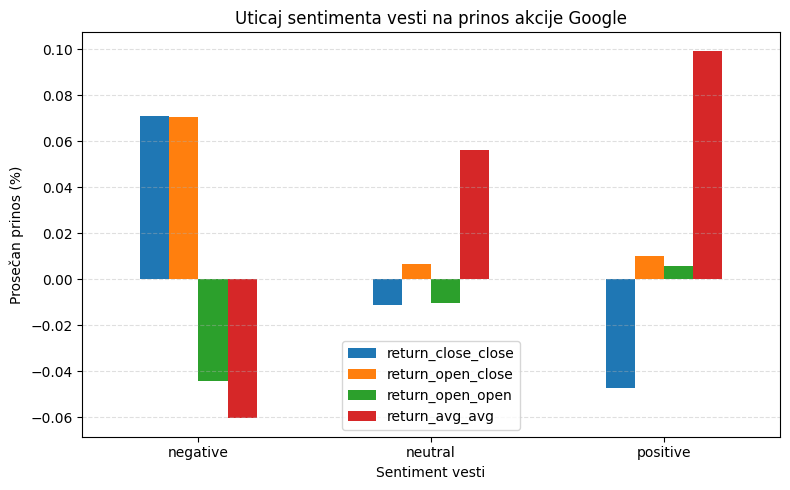

In [ ]:
import matplotlib.pyplot as plt

returns_by_sentiment = daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

# u procente
returns_by_sentiment_percent = returns_by_sentiment * 100

# plot
returns_by_sentiment_percent.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Uticaj sentimenta vesti na prinos akcije Google")
plt.xlabel("Sentiment vesti")
plt.ylabel("Prosečan prinos (%)")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

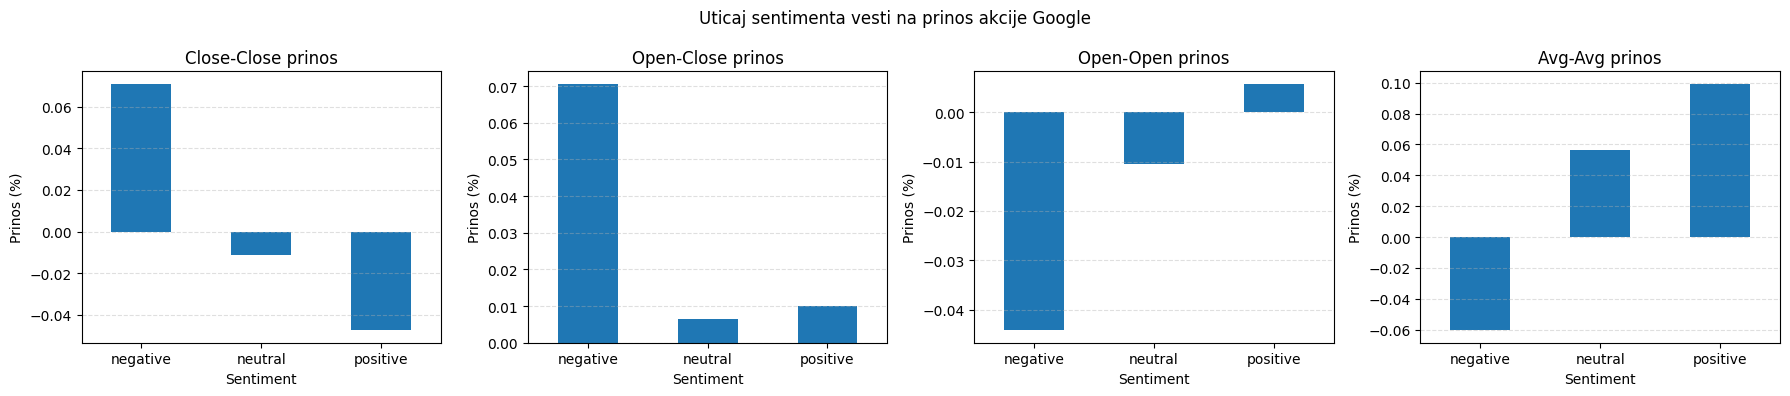

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

# Close-Close
returns_by_sentiment_percent["return_close_close"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Close-Close prinos")

# Open-Close
returns_by_sentiment_percent["return_open_close"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Open-Close prinos")

# Open-Open
returns_by_sentiment_percent["return_open_open"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Open-Open prinos")

# Avg-Avg
returns_by_sentiment_percent["return_avg_avg"].plot(kind="bar", ax=axes[3])
axes[3].set_title("Avg-Avg prinos")

for ax in axes:
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Prinos (%)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Uticaj sentimenta vesti na prinos akcije Google")

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

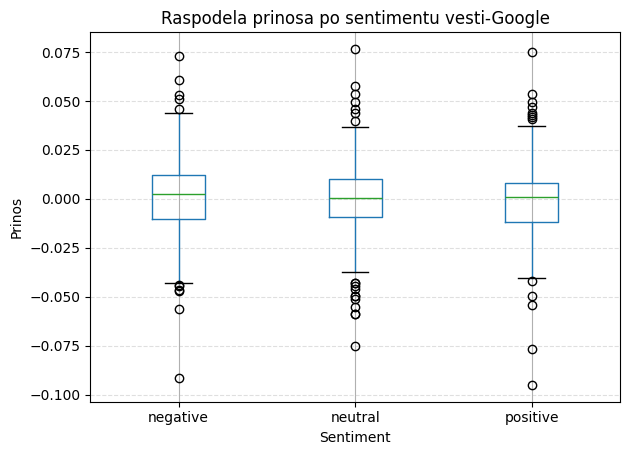

In [ ]:
import matplotlib.pyplot as plt

# kopija podataka
df_daily = daily_sentiment.copy()

# formiranje grupa na osnovu daily_sentiment_class
df_daily["sentiment_group"] = pd.cut(
    df_daily["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
)

# boxplot
plt.figure(figsize=(6,4))

df_daily.boxplot(
    column="return_close_close",
    by="sentiment_group"
)

plt.title("Raspodela prinosa po sentimentu vesti-Google")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Prinos")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

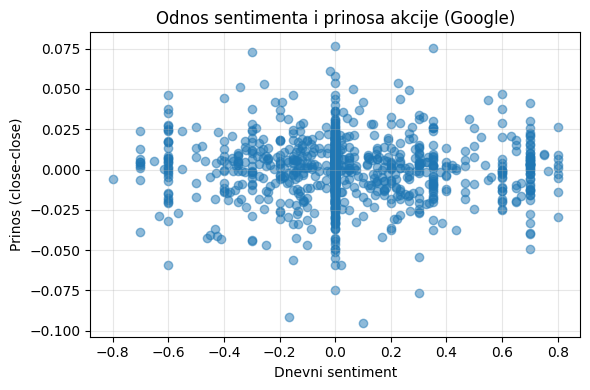

In [ ]:
import matplotlib.pyplot as plt

# uklonjeno NaN
df_daily = daily_sentiment.dropna(subset=["daily_sentiment_score", "return_close_close"])

plt.figure(figsize=(6,4))

plt.scatter(
    df_daily["daily_sentiment_score"],
    df_daily["return_close_close"],
    alpha=0.5
)

plt.title("Odnos sentimenta i prinosa akcije (Google)")
plt.xlabel("Dnevni sentiment")
plt.ylabel("Prinos (close-close)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
print(len(googl_merged))
print(len(googl_tagged))

googl_merged[["date", "title"]].head()
googl_tagged[["date", "title", "sentiment", "sentiment_score"]].head()

3662
3662


,date,title,sentiment,sentiment_score
0,2020-03-30,Buying What the Fed Buys,neutral,0.0
1,2020-05-12,Not Just Fun And Games: How Esports Could Offe...,positive,0.6
2,2020-05-13,Keep Your Virus News Away From My Ad: Brands B...,negative,-0.7
3,2020-05-14,Sony Says It Created World’s First Image Senso...,neutral,0.0
4,2020-05-19,"Sony, Microsoft Strike Deal on Tiny AI Chip Wi...",neutral,0.0


In [27]:
googl_final = googl_merged.copy()

googl_final["sentiment"] = googl_tagged["sentiment"].values
googl_final["sentiment_score"] = googl_tagged["sentiment_score"].values
googl_final["topic"] = googl_tagged["topic"].values
googl_final["sentiment_num"] = googl_tagged["sentiment_num"].values

In [28]:
googl_final["return_prof_3d"] = (
    abs(googl_final["max_high_3d"] - googl_final["close_t"]) -
    abs(googl_final["min_low_3d"] - googl_final["close_t"])
) / googl_final["close_t"]

In [29]:
googl_final.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'close_t2', 'close_t3', 'close_t5',
       'close_t7', 'open_t1', 'open_t2', 'high_t1', 'high_t2', 'high_t3',
       'low_t1', 'low_t2', 'low_t3', 'avg_t', 'avg_t1', 'return_close_close',
       'return_open_close', 'return_open_open', 'return_avg_avg', 'return_2d',
       'return_3d', 'return_5d', 'return_7d', 'y_1d', 'y_2d', 'y_3d', 'y_5d',
       'y_7d', 'max_high_3d', 'min_low_3d', 'up_move_3d', 'down_move_3d',
       'y_prof_3d', 'company', 'direction_close_close', 'direction_open_open',
       'direction_open_close', 'direction_avg_avg', 'sentiment',
       'sentiment_score', 'topic', 'sentiment_num', 'return_prof_3d'],
      dtype='object')

In [30]:
len(googl_final)

3662

In [ ]:
googl_final[["sentiment_score", "return_close_close"]].corr()

,sentiment_score,return_close_close
sentiment_score,1.000000,-0.006832
return_close_close,-0.006832,1.000000


In [ ]:
googl_final[["sentiment_score", "return_avg_avg"]].corr()

,sentiment_score,return_avg_avg
sentiment_score,1.000000,0.035527
return_avg_avg,0.035527,1.000000


In [ ]:
googl_final[["sentiment_score", "return_prof_3d"]].corr()

,sentiment_score,return_prof_3d
sentiment_score,1.000000,-0.010533
return_prof_3d,-0.010533,1.000000


In [ ]:
googl_final.groupby("y_prof_3d")["sentiment_score"].mean()

,sentiment_score
y_prof_3d,
0,0.015656
1,0.007005


In [ ]:
corr = googl_final[[
    "sentiment_score",
    "return_close_close",
    "return_avg_avg",
    "return_2d",
    "return_3d"
]].corr()

print(corr)

                    sentiment_score  return_close_close  return_avg_avg  \
sentiment_score            1.000000           -0.006832        0.035527   
return_close_close        -0.006832            1.000000        0.839451   
return_avg_avg             0.035527            0.839451        1.000000   
return_2d                 -0.010531            0.656969        0.543134   
return_3d                 -0.008263            0.515250        0.416353   

                    return_2d  return_3d  
sentiment_score     -0.010531  -0.008263  
return_close_close   0.656969   0.515250  
return_avg_avg       0.543134   0.416353  
return_2d            1.000000   0.791854  
return_3d            0.791854   1.000000  


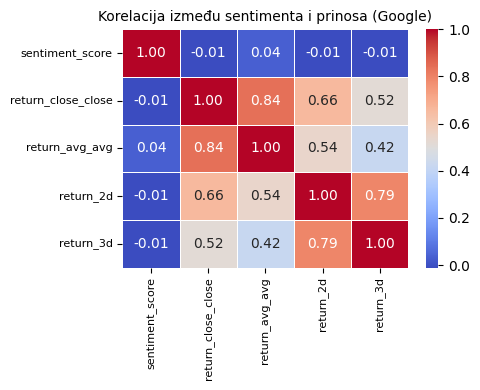

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Korelacija između sentimenta i prinosa (Google)", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()


plt.show()

In [31]:
googl_final.to_csv("/content/drive/MyDrive/googl_final.csv", index=False)